# EV2Gym Simulation and RL Training Notebook
This notebook demonstrates how to simulate and train agents in the EV2Gym environment, including visualization and evaluation of results.

In [1]:
# Section 1: Import Required Libraries
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO, A2C, DDPG, SAC, TD3
from sb3_contrib import TQC, TRPO, ARS, RecurrentPPO
from stable_baselines3.common.callbacks import EvalCallback
from wandb.integration.sb3 import WandbCallback
from ev2gym.models.ev2gym_env import EV2Gym
from ev2gym.rl_agent.reward import SquaredTrackingErrorReward, ProfitMax_TrPenalty_UserIncentives, profit_maximization
from ev2gym.rl_agent.state import V2G_profit_max, PublicPST, V2G_profit_max_loads
from ev2gym.baselines.mpc.V2GProfitMax import V2GProfitMaxOracle
from ev2gym.baselines.heuristics import ChargeAsFastAsPossible

In [2]:
# Section 2: Set Working Directory and Load Configuration Files
os.chdir("/home/helen/EV2Gym")
notebook_dir = os.path.dirname(os.path.abspath("/home/helen/EV2Gym/train_stable_baselines_notebook.ipynb"))
config_file = os.path.abspath(os.path.join(notebook_dir, "ev2gym", "example_config_files", "V2GProfitPlusLoads.yaml"))
ev_specs_file = os.path.abspath(os.path.join(notebook_dir, "ev2gym", "data", "ev_specs_ev_plus_phev.json"))
config = yaml.load(open(config_file, 'r'), Loader=yaml.FullLoader)

Creating directory: ./results/sim_2025_11_26_755740


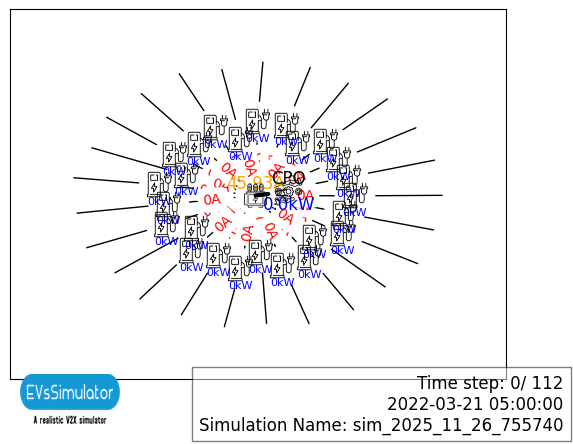

In [3]:
# Section 3: Initialize EV2Gym Environment and Agent
env = EV2Gym(config_file=config_file, render_mode=True, save_replay=True, save_plots=True)
state, _ = env.reset()
# Choose agent: Oracle or Heuristic
agent = V2GProfitMaxOracle(env, verbose=False)
# Or use: agent = ChargeAsFastAsPossible(verbose=True)

In [5]:
# Section 4: Run Simulation with Oracle/Heuristic Agent
states = []
actions = []
for t in range(env.simulation_length):
    action = agent.get_action(env)
    actions.append(action)
    new_state, reward, done, truncated, stats = env.step(action)
    states.append(new_state)
    if done:
        break

-------------------------------------------- 
 t: 0
Transformer 0:
 - tr_pv: [ -0.82383767  -1.54380256  -2.40152205  -3.34189429  -5.29224966  -7.8485949  -10.76853407 -13.90662959 -17.58155759 -21.57858508 -25.76887225 -30.07511525 -34.25291287 -38.35364327 -42.40813333 -46.4348792  -50.07864365 -53.49261926 -56.76872156 -59.96209987 -62.66030136 -65.06139675 -67.28422848 -69.40010202 -71.0062582  -72.30658398 -73.4234115  -74.43014008 -74.57873385 -74.21244673 -73.53723108 -72.67665831 -70.55636188 -67.68023126 -64.35060011 -60.74886866 -57.46902322 -54.3823094  -51.41147454 -48.51016707 -46.79908542 -45.80213925 -45.23367438 -44.92229829 -42.71568026 -39.37191706 -35.34586677 -30.91044422 -26.8234549  -22.94552551 -19.19303208 -15.51580023 -12.51738567  -9.9262615   -7.57951156  -5.37938615  -3.8513911   -2.72667427  -1.84392436  -1.10635462  -0.66381277  -0.39828766  -0.2389726   -0.14338356  -0.08603014  -0.05161808  -0.03097085  -0.01858251  -0.01114951  -0.0066897   -0.00401382

GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information

In [4]:
# Section 5: Inspect State and Actions
state, _ = env.reset()
action = agent.get_action(env)
print('Action:', action)
new_state, reward, done, truncated, stats = env.step(action)
print('New State:', new_state)

Restricted license - for non-production use only - expires 2026-11-23


KeyboardInterrupt: 

In [ ]:
# Section 6: Visualize State and Action Trajectories
df_states = pd.DataFrame(states)
df_actions = pd.DataFrame(actions)
plt.figure(figsize=(12, 6))
df_states[[0, 1, 2]].plot()
plt.title('Selected State Variables Over Time')
plt.xlabel('Timestep')
plt.ylabel('State Value')
plt.legend(['State 0', 'State 1', 'State 2'])
plt.show()
plt.figure(figsize=(12, 6))
df_actions.plot()
plt.title('Actions Over Time (per port)')
plt.xlabel('Timestep')
plt.ylabel('Action Value')
plt.legend([f'Port {i}' for i in range(df_actions.shape[1])])
plt.show()

In [5]:
# Section 7: Initialize RL Environment and Agent
reward_function = profit_maximization
state_function = PublicPST
config_file_rl = "ev2gym/example_config_files/PublicPST.yaml"
env_rl = gym.make('EV2Gym-v1',
                  config_file=config_file_rl,
                  reward_function=reward_function,
                  state_function=state_function)
model = DDPG("MlpPolicy", env_rl)

/home/helen/venvs/e2v_env/lib/python3.12/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 1.10GB > 0.20GB
  warnings.warn(


In [6]:
# Section 8: Train RL Agent
model.learn(total_timesteps=1000000, progress_bar=True)

Output()

: 

In [ ]:
# Section 9: Evaluate RL Agent
env_eval = model.get_env()
obs = env_eval.reset()
stats = []
for i in range(1000):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, info = env_eval.step(action)
    if done:
        stats.append(info)

In [ ]:
# Section 10: Process and Visualize Episode Statistics
# Flatten the list of lists
flat_stats = [item for sublist in stats for item in sublist]
# Convert numpy types to native Python types and arrays to lists
def clean_dict(d):
    clean = {}
    for k, v in d.items():
        if isinstance(v, np.ndarray):
            clean[k] = v.tolist()
        elif isinstance(v, (np.generic,)):
            clean[k] = v.item()
        else:
            clean[k] = v
    return clean
cleaned_stats = [clean_dict(d) for d in flat_stats]
df_stats = pd.DataFrame(cleaned_stats)
episode_stats = df_stats[['total_energy_charged','tracking_error']]
episode_stats.plot(subplots=True, figsize=(10,10))
plt.show()